<a href="https://colab.research.google.com/github/rfortuna98/QNC-Fall-2025/blob/main/Ex_Phe_coc_fem_anova.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


=== ANOVA: Lever Presses by Treatment ===
                     sum_sq    df         F    PR(>F)
C(treatment)   74304.181818   2.0  5.645315  0.008299
Residual      197431.454545  30.0       NaN       NaN


/tmp/ipython-input-1955017257.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if anova_table["PR(>F)"][0] < 0.05:



=== Tukey HSD Post-hoc Test ===
   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
 group1  group2  meandiff p-adj    lower    upper   reject
----------------------------------------------------------
 0ug/kg 10ug/kg -115.1818 0.0064 -200.4586  -29.905   True
 0ug/kg  3ug/kg  -71.0909 0.1166 -156.3677  14.1859  False
10ug/kg  3ug/kg   44.0909 0.4201  -41.1859 129.3677  False
----------------------------------------------------------


/tmp/ipython-input-1955017257.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


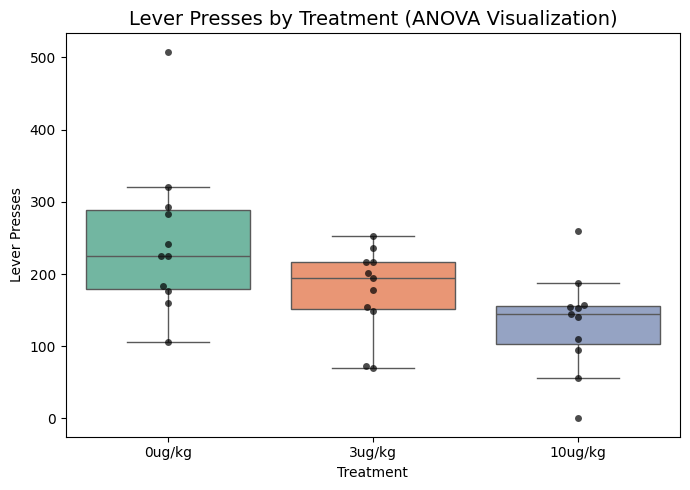

In [10]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import pearsonr

# === Load data from CSV ===
# Replace 'data.csv' with your actual filename
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Ex-phe-coc-fem RE ALxBW.csv')

# === One-way ANOVA: LeverPress ~ treatment ===
model = ols('LeverPress ~ C(treatment)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("\n=== ANOVA: Lever Presses by Treatment ===")
print(anova_table)

# === Post-hoc Tukey test (if significant) ===
if anova_table["PR(>F)"][0] < 0.05:
    tukey = pairwise_tukeyhsd(
        endog=df['LeverPress'],
        groups=df['treatment'],
        alpha=0.05
    )
    print("\n=== Tukey HSD Post-hoc Test ===")
    print(tukey)

# === Visualization: Box + Swarm Plot ===
plt.figure(figsize=(7,5))
sns.boxplot(
    data=df,
    x='treatment',
    y='LeverPress',
    palette='Set2',
    showfliers=False
)
sns.swarmplot(
    data=df,
    x='treatment',
    y='LeverPress',
    color='k',
    alpha=0.7
)
plt.title('Lever Presses by Treatment (ANOVA Visualization)', fontsize=14)
plt.xlabel('Treatment')
plt.ylabel('Lever Presses')
plt.tight_layout()
plt.show()




=== ANOVA: Lever Presses by Treatment ===
                     sum_sq    df         F    PR(>F)
C(treatment)   74304.181818   2.0  5.645315  0.008299
Residual      197431.454545  30.0       NaN       NaN


/tmp/ipython-input-2973233527.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if anova_table["PR(>F)"][0] < 0.05:



=== Tukey HSD Post-hoc Test ===
   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
 group1  group2  meandiff p-adj    lower    upper   reject
----------------------------------------------------------
 0ug/kg 10ug/kg -115.1818 0.0064 -200.4586  -29.905   True
 0ug/kg  3ug/kg  -71.0909 0.1166 -156.3677  14.1859  False
10ug/kg  3ug/kg   44.0909 0.4201  -41.1859 129.3677  False
----------------------------------------------------------


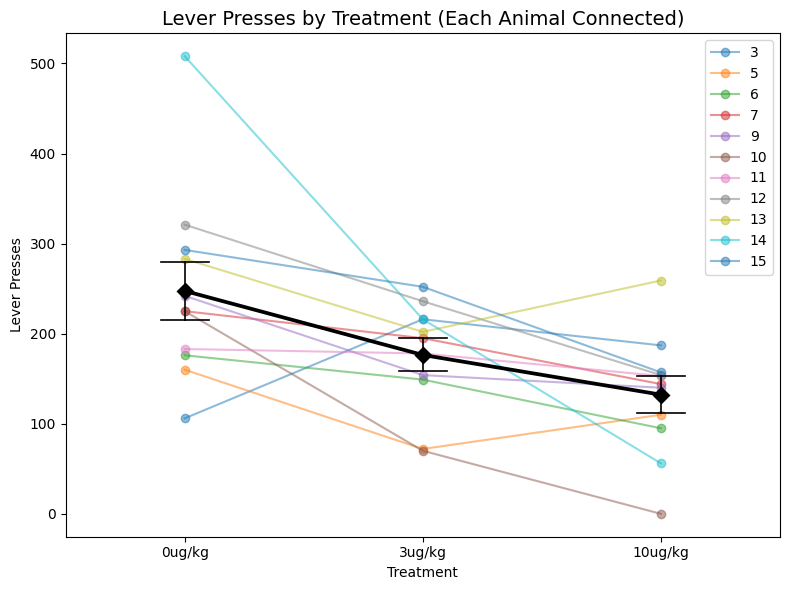

In [12]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import seaborn as sns
import matplotlib.pyplot as plt

# === One-way ANOVA: LeverPress ~ treatment ===
model = ols('LeverPress ~ C(treatment)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("\n=== ANOVA: Lever Presses by Treatment ===")
print(anova_table)

# === Post-hoc Tukey test (if significant) ===
if anova_table["PR(>F)"][0] < 0.05:
    tukey = pairwise_tukeyhsd(
        endog=df['LeverPress'],
        groups=df['treatment'],
        alpha=0.05
    )
    print("\n=== Tukey HSD Post-hoc Test ===")
    print(tukey)

# === Visualization: Each Animal Connected Across Treatments ===
plt.figure(figsize=(8,6))

# Plot each animal’s line
for animal_id, subdf in df.groupby('animal'):
    plt.plot(subdf['treatment'], subdf['LeverPress'],
             marker='o', linestyle='-', alpha=0.5, label=animal_id)

# Overlay group means
sns.pointplot(
    data=df,
    x='treatment',
    y='LeverPress',
    errorbar='se',
    color='black',
    capsize=0.2,
    markers='D',
    err_kws={'linewidth': 1.2}
)

plt.title('Lever Presses by Treatment (Each Animal Connected)', fontsize=14)
plt.xlabel('Treatment')
plt.ylabel('Lever Presses')
plt.tight_layout()
plt.show()